# Time Complexity of Ridge Regression Methods

This notebook investigates the differences between fast leave-one-out CV and EM ridge regression in terms of their computational time complexity. It differentiates between the time for the largely identical preprocessing steps and the total computation time.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from experiments import Experiment, fitting_time, svd_time, normalization_time, number_of_features
from journal2026 import (
    JOURNAL2026_TRAIN_SIZES,
    JOURNAL2026_D1_TINY, JOURNAL2026_D1_SMALL, JOURNAL2026_D1_MEDIUM, JOURNAL2026_D1_LARGE,
    TIMING_ESTIMATORS, TIMING_EST_NAMES,
)

In [2]:
def lighten(color, factor):
    r, g, b, _ = mcolors.to_rgba(color)
    return (r + (1 - r) * factor, g + (1 - g) * factor, b + (1 - b) * factor, 1.0)

BASE_COLORS   = ['#2166ac', '#d6604d', '#4dac26']
SHADE_FACTORS = [0.0, 0.30, 0.60]
HATCHES       = ['////', '..', '']
COMP_LABELS   = ['T_norm', 'T_svd', 'T_fit']
BAR_WIDTH     = 0.25
BAR_OFFSETS   = [-BAR_WIDTH, 0, BAR_WIDTH]


def timing_figure(exp, ax):
    datasets = [p.dataset for p in exp.problems]
    n = len(datasets)
    x = np.arange(n)
    for j in range(len(TIMING_EST_NAMES)):
        t_norm_mean = exp.normalization_time_[:, :, 0, j].mean(axis=0)
        t_svd_mean  = exp.svd_time_[:, :, 0, j].mean(axis=0)
        t_fit_mean  = (exp.fitting_time_[:, :, 0, j].mean(axis=0)
                       - t_svd_mean - t_norm_mean)
        t_total = exp.fitting_time_[:, :, 0, j]
        ci_lo   = np.percentile(t_total, 2.5, axis=0)
        ci_hi   = np.percentile(t_total, 97.5, axis=0)
        t_mean  = t_total.mean(axis=0)
        xpos    = x + BAR_OFFSETS[j]
        for seg_mean, shade_f, hatch, bottom in [
            (t_norm_mean, SHADE_FACTORS[0], HATCHES[0], np.zeros(n)),
            (t_svd_mean,  SHADE_FACTORS[1], HATCHES[1], t_norm_mean),
            (t_fit_mean,  SHADE_FACTORS[2], HATCHES[2], t_norm_mean + t_svd_mean),
        ]:
            ax.bar(xpos, seg_mean, width=BAR_WIDTH, bottom=bottom,
                   color=lighten(BASE_COLORS[j], shade_f),
                   hatch=hatch, edgecolor='black', linewidth=0.4)
        ax.errorbar(xpos, t_mean,
                    yerr=[t_mean - ci_lo, ci_hi - t_mean],
                    fmt='none', color='black', capsize=3, linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=45, ha='right')
    ax.set_ylabel('Time [s]')


def timing_table(exp):
    rows = []
    for i, prob in enumerate(exp.problems):
        t_em    = exp.fitting_time_[:, i, 0, 0].mean()
        t_cv11  = exp.fitting_time_[:, i, 0, 1].mean()
        t_cv101 = exp.fitting_time_[:, i, 0, 2].mean()
        t_svd   = np.stack([exp.svd_time_[:, i, 0, j] for j in range(3)]).mean()
        t_norm  = np.stack([exp.normalization_time_[:, i, 0, j] for j in range(3)]).mean()
        t_prep  = t_svd + t_norm
        rows.append({
            'dataset': prob.dataset,
            'T_EM':    round(t_em,    4),
            'T_CV11':  round(t_cv11,  4),
            'T_CV101': round(t_cv101, 4),
            'T_svd':   round(t_svd,   4),
            'T_norm':  round(t_norm,  4),
            'T_prep':  round(t_prep,  4),
            'SU':      round(t_cv101 / t_em, 2),
            'SU_post': round((t_cv101 - t_prep) / (t_em - t_prep), 2)
                       if (t_em - t_prep) > 0 else float('nan'),
        })
    return pd.DataFrame(rows).set_index('dataset')

## Tiny Datasets

In [3]:
exp_tiny = Experiment(
    JOURNAL2026_D1_TINY, TIMING_ESTIMATORS,
    reps=30, ns=[[JOURNAL2026_TRAIN_SIZES[p.dataset]] for p in JOURNAL2026_D1_TINY],
    seed=123,
    stats=[fitting_time, svd_time, normalization_time, number_of_features],
    est_names=TIMING_EST_NAMES).run()

  0%|          | 0/4 [00:00<?, ?it/s]

autompg:   0%|          | 0/90 [00:00<?, ?it/s]

autompg  —  0 computed, 90 retrieved  (0.1s)


diabetes:   0%|          | 0/90 [00:00<?, ?it/s]

diabetes  —  0 computed, 90 retrieved  (0.1s)


real_estate:   0%|          | 0/90 [00:00<?, ?it/s]

real_estate  —  0 computed, 90 retrieved  (0.1s)


yacht:   0%|          | 0/90 [00:00<?, ?it/s]

yacht  —  0 computed, 90 retrieved  (0.1s)


In [4]:
timing_table(exp_tiny)

,T_EM,T_CV11,T_CV101,T_svd,T_norm,T_prep,SU,SU_post
dataset,,,,,,,,
autompg,0.0002,0.0003,0.0011,0.0000,0.0,0.0001,5.33,8.17
diabetes,0.0002,0.0003,0.0012,0.0001,0.0,0.0001,5.28,8.82
real_estate,0.0002,0.0003,0.0010,0.0000,0.0,0.0001,5.68,9.12
yacht,0.0002,0.0002,0.0010,0.0000,0.0,0.0001,5.34,7.61


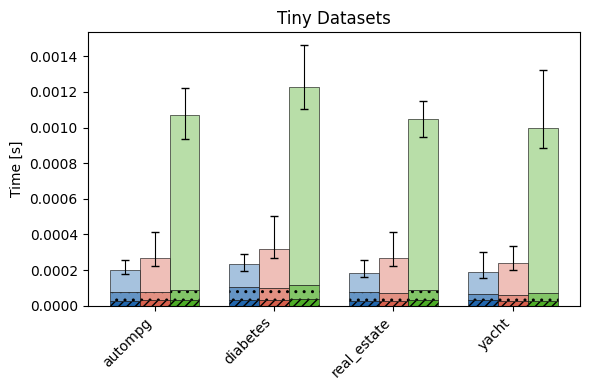

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
timing_figure(exp_tiny, ax)
ax.set_title('Tiny Datasets')
plt.tight_layout()

## Small Datasets

In [6]:
exp_small = Experiment(
    JOURNAL2026_D1_SMALL, TIMING_ESTIMATORS,
    reps=30, ns=[[JOURNAL2026_TRAIN_SIZES[p.dataset]] for p in JOURNAL2026_D1_SMALL],
    seed=123,
    stats=[fitting_time, svd_time, normalization_time, number_of_features],
    est_names=TIMING_EST_NAMES).run()

  0%|          | 0/6 [00:00<?, ?it/s]

airfoil:   0%|          | 0/90 [00:00<?, ?it/s]

airfoil  —  0 computed, 90 retrieved  (0.1s)


automobile:   0%|          | 0/90 [00:00<?, ?it/s]

automobile  —  0 computed, 90 retrieved  (0.1s)


...

concrete  —  0 computed, 90 retrieved  (0.1s)


facebook:   0%|          | 0/90 [00:00<?, ?it/s]

facebook  —  0 computed, 90 retrieved  (0.2s)


forest:   0%|          | 0/90 [00:00<?, ?it/s]

forest  —  0 computed, 90 retrieved  (0.1s)


In [7]:
timing_table(exp_small)

,T_EM,T_CV11,T_CV101,T_svd,T_norm,T_prep,SU,SU_post
dataset,,,,,,,,
airfoil,0.0002,0.0003,0.0016,0.0001,0.0000,0.0001,8.56,16.69
automobile,0.0007,0.0007,0.0019,0.0004,0.0000,0.0004,2.85,5.71
boston,0.0003,0.0004,0.0015,0.0001,0.0000,0.0001,6.04,11.18
concrete,0.0002,0.0004,0.0017,0.0001,0.0000,0.0001,7.12,13.70
facebook,0.0005,0.0006,0.0028,0.0001,0.0000,0.0002,6.15,8.95
forest,0.0020,0.0006,0.0024,0.0003,0.0001,0.0003,1.15,1.18


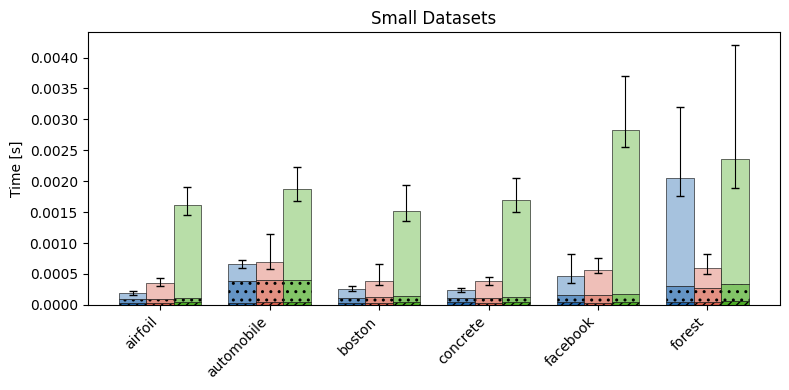

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
timing_figure(exp_small, ax)
ax.set_title('Small Datasets')
plt.tight_layout()

## Medium Datasets

In [9]:
exp_medium = Experiment(
    JOURNAL2026_D1_MEDIUM, TIMING_ESTIMATORS,
    reps=50, ns=[[JOURNAL2026_TRAIN_SIZES[p.dataset]] for p in JOURNAL2026_D1_MEDIUM],
    seed=123,
    stats=[fitting_time, svd_time, normalization_time, number_of_features],
    est_names=TIMING_EST_NAMES).run(force_recompute=True)

  0%|          | 0/7 [00:00<?, ?it/s]

abalone:   0%|          | 0/150 [00:00<?, ?it/s]

abalone  —  150 computed, 0 retrieved  (0.7s)


crime:   0%|          | 0/150 [00:00<?, ?it/s]

crime  —  150 computed, 0 retrieved  (2.1s)


...

naval_propulsion  —  150 computed, 0 retrieved  (1.4s)


parkinsons:   0%|          | 0/150 [00:00<?, ?it/s]

parkinsons  —  150 computed, 0 retrieved  (1.1s)


student:   0%|          | 0/150 [00:00<?, ?it/s]

student  —  150 computed, 0 retrieved  (0.7s)


In [10]:
timing_table(exp_medium)

,T_EM,T_CV11,T_CV101,T_svd,T_norm,T_prep,SU,SU_post
dataset,,,,,,,,
abalone,0.0004,0.0008,0.0034,0.0002,0.0001,0.0003,8.96,34.06
crime,0.0048,0.0057,0.0137,0.0041,0.0002,0.0043,2.82,18.38
ribo,0.0085,0.0070,0.0075,0.0037,0.0005,0.0042,0.89,0.78
eye,0.0032,0.0016,0.0028,0.0011,0.0001,0.0011,0.88,0.81
naval_propulsion,0.0012,0.0025,0.0122,0.0008,0.0002,0.0010,10.15,50.62
parkinsons,0.0011,0.0018,0.0079,0.0007,0.0001,0.0008,7.41,24.18
student,0.0009,0.0010,0.0038,0.0004,0.0001,0.0005,4.40,8.93


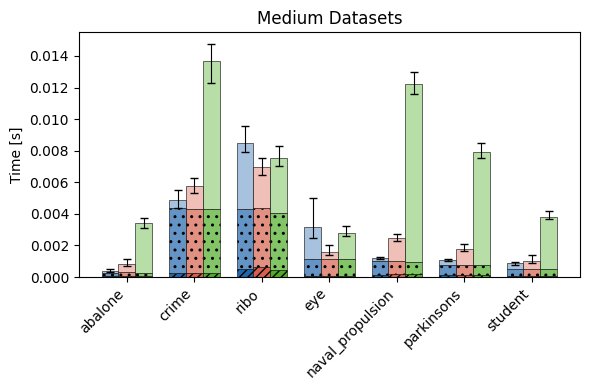

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
timing_figure(exp_medium, ax)
ax.set_title('Medium Datasets')
plt.tight_layout()

## Large Datasets

In [12]:
exp_large = Experiment(
    JOURNAL2026_D1_LARGE, TIMING_ESTIMATORS,
    reps=30, ns=[[JOURNAL2026_TRAIN_SIZES[p.dataset]] for p in JOURNAL2026_D1_LARGE],
    seed=123,
    stats=[fitting_time, svd_time, normalization_time, number_of_features],
    est_names=TIMING_EST_NAMES).run()

  0%|          | 0/4 [00:00<?, ?it/s]

twitter:   0%|          | 0/90 [00:00<?, ?it/s]

twitter  —  0 computed, 90 retrieved  (0.2s)


tomshw:   0%|          | 0/90 [00:00<?, ?it/s]

tomshw  —  0 computed, 90 retrieved  (0.1s)


blog:   0%|          | 0/90 [00:00<?, ?it/s]

blog  —  0 computed, 90 retrieved  (0.1s)


ct_slices:   0%|          | 0/90 [00:00<?, ?it/s]

ct_slices  —  0 computed, 90 retrieved  (0.1s)


In [13]:
timing_table(exp_large)

,T_EM,T_CV11,T_CV101,T_svd,T_norm,T_prep,SU,SU_post
dataset,,,,,,,,
twitter,0.4447,0.6647,2.3018,0.3526,0.0537,0.4063,5.18,49.45
tomshw,0.0390,0.0510,0.1452,0.0361,0.0020,0.0381,3.72,111.78
blog,0.1897,0.2541,0.7775,0.1761,0.0100,0.1861,4.10,164.14
ct_slices,0.2915,0.3814,1.1087,0.2718,0.0144,0.2862,3.80,155.32


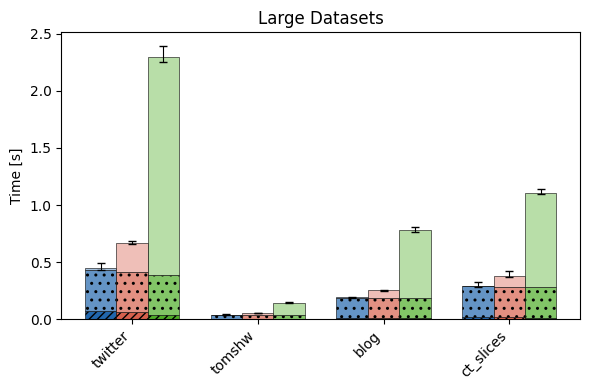

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
timing_figure(exp_large, ax)
ax.set_title('Large Datasets')
plt.tight_layout()

In [15]:
for exp, label in [(exp_tiny, 'tiny'), (exp_small, 'small'), (exp_medium, 'medium'), (exp_large, 'large')]:
    datasets = [p.dataset for p in exp.problems]
    for i, ds in enumerate(datasets):
        norm_vals = np.stack([exp.normalization_time_[:, i, 0, j]
                              for j in range(len(TIMING_EST_NAMES))])
        svd_vals  = np.stack([exp.svd_time_[:, i, 0, j]
                              for j in range(len(TIMING_EST_NAMES))])
        for name, vals in [('norm', norm_vals), ('svd', svd_vals)]:
            means = vals.mean(axis=1)
            overall_mean = means.mean()
            if overall_mean > 0 and means.std() / overall_mean > 0.10:
                print(f'WARNING [{label}] {ds}: {name} std/mean={means.std()/overall_mean:.2f}')
print('Sanity check complete')

WARNING [small] facebook: norm std/mean=0.11
WARNING [small] forest: norm std/mean=0.16
WARNING [medium] ribo: norm std/mean=0.12
WARNING [medium] student: norm std/mean=0.14
WARNING [large] twitter: norm std/mean=0.27
Sanity check complete


## Summary

In [16]:
pd.concat([timing_table(exp_tiny), timing_table(exp_small), timing_table(exp_medium), timing_table(exp_large)])

,T_EM,T_CV11,T_CV101,T_svd,T_norm,T_prep,SU,SU_post
dataset,,,,,,,,
autompg,0.0002,0.0003,0.0011,0.0000,0.0000,0.0001,5.33,8.17
diabetes,0.0002,0.0003,0.0012,0.0001,0.0000,0.0001,5.28,8.82
real_estate,0.0002,0.0003,0.0010,0.0000,0.0000,0.0001,5.68,9.12
yacht,0.0002,0.0002,0.0010,0.0000,0.0000,0.0001,5.34,7.61
airfoil,0.0002,0.0003,0.0016,0.0001,0.0000,0.0001,8.56,16.69
automobile,0.0007,0.0007,0.0019,0.0004,0.0000,0.0004,2.85,5.71
boston,0.0003,0.0004,0.0015,0.0001,0.0000,0.0001,6.04,11.18
concrete,0.0002,0.0004,0.0017,0.0001,0.0000,0.0001,7.12,13.70
facebook,0.0005,0.0006,0.0028,0.0001,0.0000,0.0002,6.15,8.95


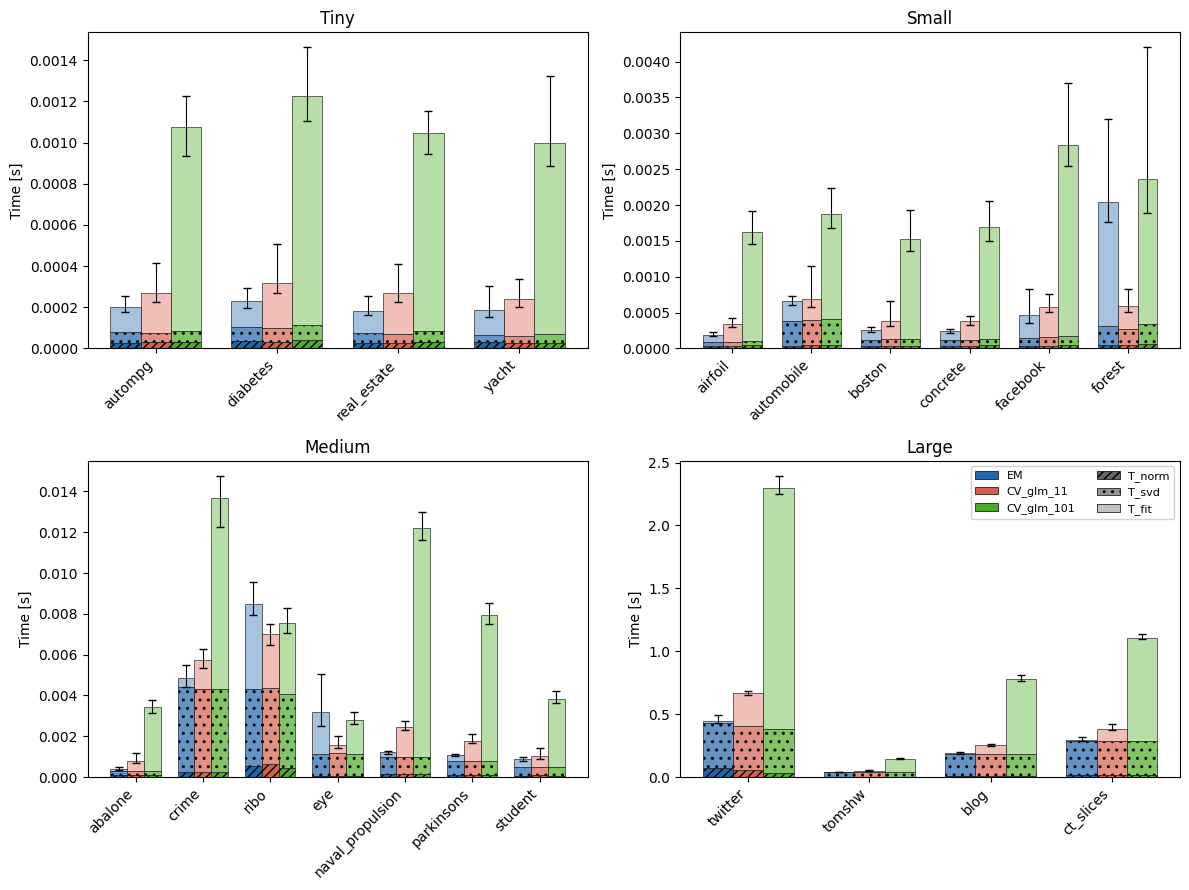

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
panels = [
    (axes[0, 0], exp_tiny,   'Tiny'),
    (axes[0, 1], exp_small,  'Small'),
    (axes[1, 0], exp_medium, 'Medium'),
    (axes[1, 1], exp_large,  'Large'),
]
for ax, exp, title in panels:
    timing_figure(exp, ax)
    ax.set_title(title)

method_handles = [mpatches.Patch(facecolor=BASE_COLORS[j], edgecolor='black',
                                  linewidth=0.5, label=TIMING_EST_NAMES[j])
                  for j in range(3)]
comp_handles = [mpatches.Patch(facecolor=lighten('#666666', SHADE_FACTORS[k]),
                                hatch=HATCHES[k], edgecolor='black',
                                linewidth=0.5, label=COMP_LABELS[k])
                for k in range(3)]
axes[1, 1].legend(handles=method_handles + comp_handles, ncol=2, fontsize=8, framealpha=0.9)
plt.tight_layout()